# 10 分级仓位第二版条件消融实验

实验目标：

1. 分析近期离场条件的边际价值；
2. 分析波动调整反弹强度的边际价值；
3. 分析快均线斜率条件的边际价值；
4. 删除冗余或过严条件；
5. 在进入新样本验证前冻结更简洁的规则。

本实验每次只移除一个条件，其他参数完全不变。

In [ ]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display


PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebook":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"

REPORT_DIR = (
    PROJECT_ROOT
    / "reports"
    / "ma_graded_position_ablation"
)

if str(SRC_DIR) not in sys.path:
    sys.path.insert(
        0,
        str(SRC_DIR),
    )

pd.set_option(
    "display.max_columns",
    160,
)

pd.set_option(
    "display.width",
    240,
)

pd.set_option(
    "display.float_format",
    lambda value: f"{value:.4f}",
)

plt.rcParams[
    "axes.unicode_minus"
] = False


from matplotlib import font_manager


def configure_chinese_font() -> str | None:
    """
    从当前系统已安装字体中选择一个支持中文的字体。
    """
    preferred_fonts = [
        "Microsoft YaHei",
        "Microsoft YaHei UI",
        "SimHei",
        "SimSun",
        "Noto Sans CJK SC",
        "Source Han Sans SC",
        "Arial Unicode MS",
    ]

    installed_fonts = {
        font.name
        for font in font_manager.fontManager.ttflist
    }

    for font_name in preferred_fonts:
        if font_name in installed_fonts:
            plt.rcParams["font.family"] = "sans-serif"
            plt.rcParams["font.sans-serif"] = [
                font_name
            ]
            plt.rcParams["axes.unicode_minus"] = False

            print(
                "Matplotlib 中文字体：",
                font_name,
            )

            return font_name

    print(
        "没有发现可用的中文字体，"
        "图中的中文可能无法正常显示"
    )

    return None


chinese_font = configure_chinese_font()

%load_ext autoreload
%autoreload 2

from backtest import (
    run_batch_ma_backtest,
)

from graded_position_strategy import (
    V2_ABLATION_SPECS,
    V2_COMBINATION_SPECS,
    run_v2_ablation_experiment,
    summarize_batch_period,
    build_timing_attribution_detail,
    summarize_timing_attribution,
    build_incremental_daily_detail,
    run_graded_condition_experiment,
)

Matplotlib 中文字体： Microsoft YaHei


In [2]:
DEVELOPMENT_STOCK_LIST = [
    "000001",
    "000002",
    "300750",
    "600036",
    "600519",
]

FAST_WINDOW = 10
SLOW_WINDOW = 40

PARTIAL_POSITION = 0.30

REBOUND_WINDOW = 5
VOLATILITY_WINDOW = 20

FAST_MA_SLOPE_WINDOW = 3
MAX_DAYS_SINCE_EXIT = 20
REBOUND_SCORE_THRESHOLD = 1.0

COMMISSION_RATE = 0.0003
SLIPPAGE_RATE = 0.0002

ANNUAL_RISK_FREE_RATE = 0.0
TRADING_DAYS = 252

DEVELOPMENT_START_DATE = "2018-01-01"
DEVELOPMENT_END_DATE = "2024-12-31"

### 运行二元基准策略

In [3]:
binary_summary_all, binary_results = (
    run_batch_ma_backtest(
        stock_list=(
            DEVELOPMENT_STOCK_LIST
        ),
        fast_window=FAST_WINDOW,
        slow_window=SLOW_WINDOW,
        commission_rate=(
            COMMISSION_RATE
        ),
        slippage_rate=(
            SLIPPAGE_RATE
        ),
        annual_risk_free_rate=(
            ANNUAL_RISK_FREE_RATE
        ),
        trading_days=TRADING_DAYS,
        save_result=False,
    )
)

正在回测：000001
正在回测：000002
正在回测：300750
正在回测：600036
正在回测：600519


### 运行消融实验

In [4]:
(
    ablation_summary_all,
    ablation_results,
) = run_v2_ablation_experiment(
    stock_list=(
        DEVELOPMENT_STOCK_LIST
    ),
    fast_window=FAST_WINDOW,
    slow_window=SLOW_WINDOW,
    rebound_window=REBOUND_WINDOW,
    partial_position=PARTIAL_POSITION,
    volatility_window=(
        VOLATILITY_WINDOW
    ),
    fast_ma_slope_window=(
        FAST_MA_SLOPE_WINDOW
    ),
    max_days_since_exit=(
        MAX_DAYS_SINCE_EXIT
    ),
    rebound_score_threshold=(
        REBOUND_SCORE_THRESHOLD
    ),
    commission_rate=(
        COMMISSION_RATE
    ),
    slippage_rate=(
        SLIPPAGE_RATE
    ),
    annual_risk_free_rate=(
        ANNUAL_RISK_FREE_RATE
    ),
    trading_days=TRADING_DAYS,
    save_result=False,
)


运行消融版本：v2_full
正在回测 v2：000001
正在回测 v2：000002
正在回测 v2：300750
正在回测 v2：600036
正在回测 v2：600519

运行消融版本：v2_no_recent_exit
正在回测 v2：000001
正在回测 v2：000002
正在回测 v2：300750
正在回测 v2：600036
正在回测 v2：600519

运行消融版本：v2_no_rebound_score
正在回测 v2：000001
正在回测 v2：000002
正在回测 v2：300750
正在回测 v2：600036
正在回测 v2：600519

运行消融版本：v2_no_fast_ma_slope
正在回测 v2：000001
正在回测 v2：000002
正在回测 v2：300750
正在回测 v2：600036
正在回测 v2：600519


## 正确性测试


In [5]:
expected_variants = set(
    V2_ABLATION_SPECS
)

actual_variants = set(
    ablation_results
)

assert actual_variants == expected_variants

print("消融版本完整性检查通过")

binary_symbols = set(
    binary_results
)

for variant, batch_results in (
    ablation_results.items()
):
    assert (
        set(batch_results)
        == binary_symbols
    ), (
        f"{variant} 股票集合不一致"
    )

print("各版本股票集合一致")

common_feature_columns = [
    "date",
    "close",
    "asset_return",
    "fast_ma",
    "slow_ma",
    "binary_signal",
    "rebound_return",
    "daily_volatility",
    "rebound_score",
    "fast_ma_slope",
    "days_since_exit",
]

full_results = (
    ablation_results[
        "v2_full"
    ]
)

for variant, batch_results in (
    ablation_results.items()
):
    for symbol in binary_symbols:
        full = (
            full_results[symbol]
            .reset_index(drop=True)
        )

        candidate = (
            batch_results[symbol]
            .reset_index(drop=True)
        )

        assert len(full) == len(
            candidate
        )

        for column in common_feature_columns:
            if column == "date":
                assert full[
                    column
                ].equals(
                    candidate[column]
                )
            else:
                assert np.allclose(
                    full[column],
                    candidate[column],
                    equal_nan=True,
                ), (
                    f"{variant} "
                    f"{symbol} "
                    f"{column} 不一致"
                )

print("公共指标一致性检查通过")

for variant, batch_results in (
    ablation_results.items()
):
    if variant == "v2_full":
        continue

    for symbol in binary_symbols:
        full_signal = (
            full_results[symbol][
                "partial_rebound_signal"
            ]
        )

        candidate_signal = (
            batch_results[symbol][
                "partial_rebound_signal"
            ]
        )

        assert (
            ~full_signal
            | candidate_signal
        ).all(), (
            f"{variant} {symbol} "
            "移除条件后丢失了原有信号"
        )

        assert (
            batch_results[symbol][
                "signal"
            ]
            + 1e-12
            >= full_results[symbol][
                "signal"
            ]
        ).all(), (
            f"{variant} {symbol} "
            "移除条件后目标仓位反而降低"
        )

print("消融信号包含关系检查通过")

ONE_WAY_COST = (
    COMMISSION_RATE
    + SLIPPAGE_RATE
)

allowed_positions = np.array(
    [
        0.0,
        PARTIAL_POSITION,
        1.0,
    ]
)

for variant, batch_results in (
    ablation_results.items()
):
    for symbol, result in (
        batch_results.items()
    ):
        valid_position = (
            result["position"]
            .apply(
                lambda value: np.isclose(
                    value,
                    allowed_positions,
                ).any()
            )
        )

        assert valid_position.all()

        expected_position = (
            result["signal"]
            .shift(1)
            .fillna(0.0)
        )

        expected_cost = (
            result[
                "position_change"
            ].abs()
            * ONE_WAY_COST
        )

        expected_gross = (
            result["position"]
            * result[
                "asset_return"
            ].fillna(0.0)
        )

        expected_net = (
            expected_gross
            - expected_cost
        )

        assert np.allclose(
            result["position"],
            expected_position,
        )

        assert np.allclose(
            result[
                "transaction_cost"
            ],
            expected_cost,
        )

        assert np.allclose(
            result[
                "gross_strategy_return"
            ],
            expected_gross,
        )

        assert np.allclose(
            result["strategy_return"],
            expected_net,
        )

print("仓位、成本与收益检查通过")


消融版本完整性检查通过
各版本股票集合一致
公共指标一致性检查通过
消融信号包含关系检查通过
仓位、成本与收益检查通过


## 绩效对比

In [18]:
binary_period_summary = (
    summarize_batch_period(
        batch_results=binary_results,
        period_name="development",
        start_date=(
            DEVELOPMENT_START_DATE
        ),
        end_date=(
            DEVELOPMENT_END_DATE
        ),
        strategy_name="binary_10_40",
        annual_risk_free_rate=(
            ANNUAL_RISK_FREE_RATE
        ),
        trading_days=TRADING_DAYS,
    )
)

ablation_period_summaries = {}

for variant, batch_results in (
    ablation_results.items()
):
    summary = summarize_batch_period(
        batch_results=batch_results,
        period_name="development",
        start_date=(
            DEVELOPMENT_START_DATE
        ),
        end_date=(
            DEVELOPMENT_END_DATE
        ),
        strategy_name=variant,
        annual_risk_free_rate=(
            ANNUAL_RISK_FREE_RATE
        ),
        trading_days=TRADING_DAYS,
    )

    summary[
        "strategy_variant"
    ] = variant

    ablation_period_summaries[
        variant
    ] = summary
    
ablation_period_detail = pd.concat(
    ablation_period_summaries.values(),
    ignore_index=True,
)

display(
    ablation_period_detail.sort_values(
        [
            "strategy_variant",
            "symbol",
        ]
    )
)
    

,period,symbol,start_date,end_date,trade_days,strategy_cumulative_return,strategy_annual_return,strategy_annual_volatility,strategy_sharpe,strategy_max_drawdown,strategy_calmar,benchmark_cumulative_return,benchmark_annual_return,benchmark_annual_volatility,benchmark_sharpe,benchmark_max_drawdown,benchmark_calmar,excess_annual_return,sharpe_diff,drawdown_improvement,exposure,buy_count,sell_count,total_trade_count,total_transaction_cost,strategy_name,total_turnover,full_position_rate,partial_position_rate,cash_rate,strategy_variant
3,development,000001,2018-01-02,2024-12-31,1699,-0.1903,-0.0308,0.2342,-0.0171,-0.4899,-0.0629,0.0570,0.0083,0.3201,0.1848,-0.6231,0.0132,-0.0391,-0.2019,0.1332,0.4762,38,33,71,0.0274,v2_full,54.8000,0.4715,0.0159,0.5127,v2_full
4,development,000002,2018-01-02,2024-12-31,1699,-0.7543,-0.1880,0.2498,-0.7089,-0.8435,-0.2228,-0.6907,-0.1597,0.3711,-0.2849,-0.7999,-0.1997,-0.0282,-0.4241,-0.0437,0.4038,45,42,87,0.0329,v2_full,65.8000,0.3985,0.0177,0.5839,v2_full
0,development,300750,2018-08-07,2024-12-31,1554,6.6310,0.3903,0.3700,1.0730,-0.3369,1.1587,6.1282,0.3751,0.4654,0.9147,-0.6288,0.5965,0.0153,0.1582,0.2919,0.5652,30,26,56,0.0223,v2_full,44.6000,0.5611,0.0135,0.4254,v2_full
2,development,600036,2018-01-02,2024-12-31,1699,-0.1093,-0.0170,0.2075,0.0206,-0.3218,-0.0529,0.7728,0.0886,0.2925,0.4360,-0.5093,0.1740,-0.1057,-0.4154,0.1875,0.5258,48,43,91,0.0332,v2_full,66.4000,0.5185,0.0241,0.4573,v2_full
1,development,600519,2018-01-02,2024-12-31,1699,0.2633,0.0353,0.2103,0.2700,-0.4325,0.0815,1.5030,0.1458,0.3060,0.5974,-0.4748,0.3070,-0.1105,-0.3274,0.0423,0.5269,40,37,77,0.0279,v2_full,55.8000,0.5227,0.0141,0.4632,v2_full
18,development,000001,2018-01-02,2024-12-31,1699,-0.1820,-0.0294,0.2344,-0.0105,-0.4853,-0.0605,0.0570,0.0083,0.3201,0.1848,-0.6231,0.0132,-0.0376,-0.1953,0.1379,0.4790,44,39,83,0.0292,v2_no_fast_ma_slope,58.4000,0.4715,0.0253,0.5032,v2_no_fast_ma_slope
19,development,000002,2018-01-02,2024-12-31,1699,-0.7627,-0.1921,0.2500,-0.7287,-0.8479,-0.2266,-0.6907,-0.1597,0.3711,-0.2849,-0.7999,-0.1997,-0.0324,-0.4439,-0.0480,0.4062,53,50,103,0.0353,v2_no_fast_ma_slope,70.6000,0.3985,0.0259,0.5756,v2_no_fast_ma_slope
15,development,300750,2018-08-07,2024-12-31,1554,6.8103,0.3956,0.3702,1.0828,-0.3354,1.1793,6.1282,0.3751,0.4654,0.9147,-0.6288,0.5965,0.0205,0.1681,0.2934,0.5677,38,33,71,0.0244,v2_no_fast_ma_slope,48.8000,0.5611,0.0219,0.4170,v2_no_fast_ma_slope
17,development,600036,2018-01-02,2024-12-31,1699,-0.0806,-0.0124,0.2077,0.0433,-0.3119,-0.0397,0.7728,0.0886,0.2925,0.4360,-0.5093,0.1740,-0.1010,-0.3926,0.1975,0.5290,53,48,101,0.0347,v2_no_fast_ma_slope,69.4000,0.5185,0.0347,0.4467,v2_no_fast_ma_slope
16,development,600519,2018-01-02,2024-12-31,1699,0.2551,0.0343,0.2105,0.2654,-0.4372,0.0784,1.5030,0.1458,0.3060,0.5974,-0.4748,0.3070,-0.1115,-0.3320,0.0376,0.5301,50,47,97,0.0309,v2_no_fast_ma_slope,61.8000,0.5227,0.0247,0.4526,v2_no_fast_ma_slope


In [7]:
COMPARISON_METRICS = [
    "strategy_annual_return",
    "strategy_sharpe",
    "strategy_max_drawdown",
    "strategy_calmar",
    "excess_annual_return",
    "exposure",
    "total_trade_count",
    "total_transaction_cost",
    "total_turnover",
    "partial_position_rate",
]


def compare_period_summaries(
    baseline: pd.DataFrame,
    candidate: pd.DataFrame,
    baseline_name: str,
    candidate_name: str,
) -> pd.DataFrame:
    baseline_data = baseline[
        [
            "symbol",
            *COMPARISON_METRICS,
        ]
    ].copy()

    candidate_data = candidate[
        [
            "symbol",
            *COMPARISON_METRICS,
        ]
    ].copy()

    comparison = baseline_data.merge(
        candidate_data,
        on="symbol",
        how="inner",
        suffixes=(
            "_baseline",
            "_candidate",
        ),
        validate="one_to_one",
    )

    comparison[
        "baseline_name"
    ] = baseline_name

    comparison[
        "candidate_name"
    ] = candidate_name

    for metric in COMPARISON_METRICS:
        comparison[
            f"{metric}_diff"
        ] = (
            comparison[
                f"{metric}_candidate"
            ]
            - comparison[
                f"{metric}_baseline"
            ]
        )

    return comparison

def summarize_comparison(
    comparison: pd.DataFrame,
) -> dict:
    return {
        "baseline_name": (
            comparison[
                "baseline_name"
            ].iloc[0]
        ),
        "candidate_name": (
            comparison[
                "candidate_name"
            ].iloc[0]
        ),
        "stock_count": int(
            comparison[
                "symbol"
            ].nunique()
        ),
        "avg_annual_return_diff": float(
            comparison[
                "strategy_annual_return_diff"
            ].mean()
        ),
        "annual_return_win_rate": float(
            comparison[
                "strategy_annual_return_diff"
            ].gt(0).mean()
        ),
        "avg_sharpe_diff": float(
            comparison[
                "strategy_sharpe_diff"
            ].mean()
        ),
        "sharpe_win_rate": float(
            comparison[
                "strategy_sharpe_diff"
            ].gt(0).mean()
        ),
        "avg_drawdown_diff": float(
            comparison[
                "strategy_max_drawdown_diff"
            ].mean()
        ),
        "drawdown_win_rate": float(
            comparison[
                "strategy_max_drawdown_diff"
            ].gt(0).mean()
        ),
        "avg_excess_return_diff": float(
            comparison[
                "excess_annual_return_diff"
            ].mean()
        ),
        "avg_exposure_diff": float(
            comparison[
                "exposure_diff"
            ].mean()
        ),
        "avg_trade_count_diff": float(
            comparison[
                "total_trade_count_diff"
            ].mean()
        ),
        "avg_turnover_diff": float(
            comparison[
                "total_turnover_diff"
            ].mean()
        ),
        "avg_transaction_cost_diff": float(
            comparison[
                "total_transaction_cost_diff"
            ].mean()
        ),
        "avg_partial_position_rate_diff": float(
            comparison[
                "partial_position_rate_diff"
            ].mean()
        ),
    }

In [8]:
full_period_summary = (
    ablation_period_summaries[
        "v2_full"
    ]
)

ablation_comparisons = {}
ablation_comparison_rows = []

for variant in V2_ABLATION_SPECS:
    if variant == "v2_full":
        continue

    comparison = (
        compare_period_summaries(
            baseline=(
                full_period_summary
            ),
            candidate=(
                ablation_period_summaries[
                    variant
                ]
            ),
            baseline_name="v2_full",
            candidate_name=variant,
        )
    )

    ablation_comparisons[
        variant
    ] = comparison

    ablation_comparison_rows.append(
        summarize_comparison(
            comparison
        )
    )

ablation_performance_summary = (
    pd.DataFrame(
        ablation_comparison_rows
    )
)

display(ablation_performance_summary)

,baseline_name,candidate_name,stock_count,avg_annual_return_diff,annual_return_win_rate,avg_sharpe_diff,sharpe_win_rate,avg_drawdown_diff,drawdown_win_rate,avg_excess_return_diff,avg_exposure_diff,avg_trade_count_diff,avg_turnover_diff,avg_transaction_cost_diff,avg_partial_position_rate_diff
0,v2_full,v2_no_recent_exit,5,0.0013,0.8000,0.0051,0.8000,-0.0003,0.6000,0.0013,0.0083,32.6000,7.5600,0.0038,0.0275
1,v2_full,v2_no_rebound_score,5,0.0006,0.8000,0.0079,0.8000,0.0063,0.8000,0.0006,0.0083,13.6000,2.4600,0.0012,0.0276
2,v2_full,v2_no_fast_ma_slope,5,0.0012,0.6000,0.0030,0.6000,0.0014,0.6000,0.0012,0.0028,14.6000,4.3200,0.0022,0.0094


In [9]:
def select_evaluation_data(
    result: pd.DataFrame,
) -> pd.DataFrame:
    data = result.copy()

    data["date"] = pd.to_datetime(
        data["date"]
    )

    mask = (
        data["slow_ma"]
        .shift(1)
        .notna()
    )

    mask &= data["date"].between(
        DEVELOPMENT_START_DATE,
        DEVELOPMENT_END_DATE,
    )

    return (
        data.loc[mask]
        .copy()
        .reset_index(drop=True)
    )
    
def summarize_variant_signal_quality(
    variant: str,
    batch_results: dict[
        str,
        pd.DataFrame,
    ],
) -> dict:
    frames = []

    for symbol, result in (
        batch_results.items()
    ):
        data = select_evaluation_data(
            result
        )

        frames.append(data)

    combined = pd.concat(
        frames,
        ignore_index=True,
    )

    signal_mask = (
        combined["signal_state"]
        == "partial"
    )

    position_mask = (
        combined["position_state"]
        == "partial"
    )

    previous_state = (
        combined.groupby("symbol")[
            "position_state"
        ]
        .shift(1)
        .fillna("cash")
    )

    entry_mask = (
        position_mask
        & (
            previous_state != "partial"
        )
    )

    partial_position_data = (
        combined.loc[
            position_mask
        ]
    )

    partial_signal_data = (
        combined.loc[
            signal_mask
        ]
    )

    partial_signal_days = int(
        signal_mask.sum()
    )

    partial_entry_count = int(
        entry_mask.sum()
    )

    partial_net_return_sum = float(
        partial_position_data[
            "strategy_return"
        ].sum()
    )

    return {
        "strategy_variant": variant,
        "observation_count": int(
            len(combined)
        ),
        "partial_signal_days": (
            partial_signal_days
        ),
        "partial_position_days": int(
            position_mask.sum()
        ),
        "partial_position_rate": float(
            position_mask.mean()
        ),
        "partial_entry_count": (
            partial_entry_count
        ),
        "avg_days_since_exit_at_signal": float(
            partial_signal_data[
                "days_since_exit"
            ].mean()
        ),
        "median_days_since_exit_at_signal": float(
            partial_signal_data[
                "days_since_exit"
            ].median()
        ),
        "avg_rebound_score_at_signal": float(
            partial_signal_data[
                "rebound_score"
            ].mean()
        ),
        "avg_fast_ma_slope_at_signal": float(
            partial_signal_data[
                "fast_ma_slope"
            ].mean()
        ),
        "partial_day_avg_asset_return": float(
            partial_position_data[
                "asset_return"
            ].mean()
        ),
        "partial_day_positive_rate": float(
            partial_position_data[
                "asset_return"
            ].gt(0).mean()
        ),
        "partial_day_net_return_sum": (
            partial_net_return_sum
        ),
        "net_return_per_signal_day": (
            partial_net_return_sum
            / partial_signal_days
            if partial_signal_days > 0
            else np.nan
        ),
        "net_return_per_entry": (
            partial_net_return_sum
            / partial_entry_count
            if partial_entry_count > 0
            else np.nan
        ),
        "total_turnover": float(
            combined["turnover"].sum()
        ),
        "transaction_cost_sum": float(
            combined[
                "transaction_cost"
            ].sum()
        ),
    }
    
signal_quality_summary = pd.DataFrame(
    [
        summarize_variant_signal_quality(
            variant,
            batch_results,
        )
        for variant, batch_results
        in ablation_results.items()
    ]
)

display(signal_quality_summary)

,strategy_variant,observation_count,partial_signal_days,partial_position_days,partial_position_rate,partial_entry_count,avg_days_since_exit_at_signal,median_days_since_exit_at_signal,avg_rebound_score_at_signal,avg_fast_ma_slope_at_signal,partial_day_avg_asset_return,partial_day_positive_rate,partial_day_net_return_sum,net_return_per_signal_day,net_return_per_entry,total_turnover,transaction_cost_sum
0,v2_full,8350,143,143,0.0171,73,11.1329,11.0000,1.5702,0.0104,0.0025,0.4825,0.0968,0.0007,0.0013,287.4000,0.1437
1,v2_no_recent_exit,8350,373,373,0.0447,173,32.4370,26.0000,1.5674,0.0136,0.0015,0.4638,0.1405,0.0004,0.0008,325.2000,0.1626
2,v2_no_rebound_score,8350,375,375,0.0449,120,11.5600,11.0000,0.8532,0.0097,0.0014,0.4960,0.1411,0.0004,0.0012,299.7000,0.1498
3,v2_no_fast_ma_slope,8350,222,222,0.0266,110,10.2297,9.5000,1.4738,0.0037,0.0022,0.5045,0.1273,0.0006,0.0012,309.0000,0.1545


## 分析消融条件下额外仓位的贡献

In [10]:
def summarize_removed_condition_effect(
    variant: str,
    full_results: dict[
        str,
        pd.DataFrame,
    ],
    ablated_results: dict[
        str,
        pd.DataFrame,
    ],
) -> tuple[
    dict,
    pd.DataFrame,
]:
    incremental_detail = (
        build_incremental_daily_detail(
            binary_results=full_results,
            graded_results=(
                ablated_results
            ),
            start_date=(
                DEVELOPMENT_START_DATE
            ),
            end_date=(
                DEVELOPMENT_END_DATE
            ),
        )
    )

    # 移除 AND 条件后，仓位理论上只能增加。
    assert (
        incremental_detail[
            "position_increment"
        ]
        >= -1e-12
    ).all()

    extra_exposure = (
        incremental_detail.loc[
            incremental_detail[
                "position_increment"
            ] > 1e-12
        ]
        .copy()
    )

    stock_incremental = (
        incremental_detail.groupby(
            "symbol",
            as_index=False,
        )
        .agg(
            incremental_log_return_sum=(
                "incremental_log_return",
                "sum",
            ),
            incremental_net_return_sum=(
                "incremental_net_return",
                "sum",
            ),
        )
    )

    if extra_exposure.empty:
        result = {
            "candidate_name": variant,
            "extra_exposure_days": 0,
            "extra_exposure_stock_count": 0,
            "avg_position_increment": 0.0,
            "extra_exposure_avg_asset_return": np.nan,
            "extra_exposure_positive_rate": np.nan,
            "incremental_gross_return_sum": 0.0,
            "incremental_cost_sum": 0.0,
            "incremental_net_return_sum": 0.0,
            "incremental_log_return_sum": 0.0,
            "incremental_stock_win_rate": 0.0,
        }

        return result, incremental_detail

    result = {
        "candidate_name": variant,
        "extra_exposure_days": int(
            len(extra_exposure)
        ),
        "extra_exposure_stock_count": int(
            extra_exposure[
                "symbol"
            ].nunique()
        ),
        "avg_position_increment": float(
            extra_exposure[
                "position_increment"
            ].mean()
        ),
        "extra_exposure_avg_asset_return": float(
            extra_exposure[
                "asset_return"
            ].mean()
        ),
        "extra_exposure_positive_rate": float(
            extra_exposure[
                "asset_return"
            ].gt(0).mean()
        ),
        "incremental_gross_return_sum": float(
            incremental_detail[
                "incremental_gross_return"
            ].sum()
        ),
        "incremental_cost_sum": float(
            incremental_detail[
                "incremental_transaction_cost"
            ].sum()
        ),
        "incremental_net_return_sum": float(
            incremental_detail[
                "incremental_net_return"
            ].sum()
        ),
        "incremental_log_return_sum": float(
            incremental_detail[
                "incremental_log_return"
            ].sum()
        ),
        "incremental_stock_win_rate": float(
            stock_incremental[
                "incremental_log_return_sum"
            ].gt(0).mean()
        ),
    }

    return result, incremental_detail

removed_condition_rows = []
removed_condition_details = {}

for variant, batch_results in (
    ablation_results.items()
):
    if variant == "v2_full":
        continue

    (
        summary_row,
        incremental_detail,
    ) = summarize_removed_condition_effect(
        variant=variant,
        full_results=full_results,
        ablated_results=batch_results,
    )

    removed_condition_rows.append(
        summary_row
    )

    removed_condition_details[
        variant
    ] = incremental_detail

removed_condition_effect = (
    pd.DataFrame(
        removed_condition_rows
    )
)

display(removed_condition_effect)

,candidate_name,extra_exposure_days,extra_exposure_stock_count,avg_position_increment,extra_exposure_avg_asset_return,extra_exposure_positive_rate,incremental_gross_return_sum,incremental_cost_sum,incremental_net_return_sum,incremental_log_return_sum,incremental_stock_win_rate
0,v2_no_recent_exit,230,5,0.3000,0.0009,0.4522,0.0587,0.0189,0.0398,0.0351,0.8000
1,v2_no_rebound_score,232,5,0.3000,0.0007,0.5043,0.0514,0.0061,0.0453,0.0416,0.8000
2,v2_no_fast_ma_slope,79,5,0.3000,0.0015,0.5443,0.0361,0.0108,0.0253,0.0239,0.6000


## 市场状态与策略分析

In [11]:
attribution_details = []

binary_attribution_detail = (
    build_timing_attribution_detail(
        batch_results=binary_results,
        strategy_name="binary_10_40",
        start_date=(
            DEVELOPMENT_START_DATE
        ),
        end_date=(
            DEVELOPMENT_END_DATE
        ),
    )
)

attribution_details.append(
    binary_attribution_detail
)

for variant, batch_results in (
    ablation_results.items()
):
    detail = (
        build_timing_attribution_detail(
            batch_results=batch_results,
            strategy_name=variant,
            start_date=(
                DEVELOPMENT_START_DATE
            ),
            end_date=(
                DEVELOPMENT_END_DATE
            ),
        )
    )

    attribution_details.append(
        detail
    )

all_attribution_detail = pd.concat(
    attribution_details,
    ignore_index=True,
)

attribution_summary = (
    summarize_timing_attribution(
        attribution_detail=(
            all_attribution_detail
        ),
        group_columns=[
            "strategy_name",
        ],
    )
)

display(
    attribution_summary[
        [
            "strategy_name",
            "active_return_sum",
            "active_log_return_sum",
            "missed_upside_loss",
            "avoided_downside_benefit",
            "transaction_cost_loss",
            "benefit_cost_ratio",
        ]
    ]
)

,strategy_name,active_return_sum,active_log_return_sum,missed_upside_loss,avoided_downside_benefit,transaction_cost_loss,benefit_cost_ratio
0,binary_10_40,-2.8560,-1.8892,33.9557,31.2272,0.1275,0.9162
1,v2_full,-2.7645,-1.8008,33.5897,30.9689,0.1437,0.9180
2,v2_no_fast_ma_slope,-2.7392,-1.7769,33.4032,30.8185,0.1545,0.9184
3,v2_no_rebound_score,-2.7192,-1.7592,33.0825,30.5131,0.1498,0.9182
4,v2_no_recent_exit,-2.7247,-1.7657,33.0283,30.4662,0.1626,0.9179


In [12]:
ablation_final_summary = (
    ablation_performance_summary.merge(
        signal_quality_summary,
        left_on="candidate_name",
        right_on="strategy_variant",
        how="left",
        validate="one_to_one",
    )
    .merge(
        removed_condition_effect,
        on="candidate_name",
        how="left",
        validate="one_to_one",
        suffixes=(
            "",
            "_removed_effect",
        ),
    )
)

ablation_final_columns = [
    "candidate_name",
    "partial_position_rate",
    "partial_entry_count",
    "avg_annual_return_diff",
    "annual_return_win_rate",
    "avg_sharpe_diff",
    "sharpe_win_rate",
    "avg_drawdown_diff",
    "drawdown_win_rate",
    "avg_turnover_diff",
    "avg_transaction_cost_diff",
    "extra_exposure_days",
    "extra_exposure_avg_asset_return",
    "extra_exposure_positive_rate",
    "incremental_net_return_sum",
    "incremental_log_return_sum",
    "incremental_stock_win_rate",
    "net_return_per_signal_day",
    "net_return_per_entry",
]

display(
    ablation_final_summary[
        ablation_final_columns
    ]
)

,candidate_name,partial_position_rate,partial_entry_count,avg_annual_return_diff,annual_return_win_rate,avg_sharpe_diff,sharpe_win_rate,avg_drawdown_diff,drawdown_win_rate,avg_turnover_diff,avg_transaction_cost_diff,extra_exposure_days,extra_exposure_avg_asset_return,extra_exposure_positive_rate,incremental_net_return_sum,incremental_log_return_sum,incremental_stock_win_rate,net_return_per_signal_day,net_return_per_entry
0,v2_no_recent_exit,0.0447,173,0.0013,0.8000,0.0051,0.8000,-0.0003,0.6000,7.5600,0.0038,230,0.0009,0.4522,0.0398,0.0351,0.8000,0.0004,0.0008
1,v2_no_rebound_score,0.0449,120,0.0006,0.8000,0.0079,0.8000,0.0063,0.8000,2.4600,0.0012,232,0.0007,0.5043,0.0453,0.0416,0.8000,0.0004,0.0012
2,v2_no_fast_ma_slope,0.0266,110,0.0012,0.6000,0.0030,0.6000,0.0014,0.6000,4.3200,0.0022,79,0.0015,0.5443,0.0253,0.0239,0.6000,0.0006,0.0012


## 绘图


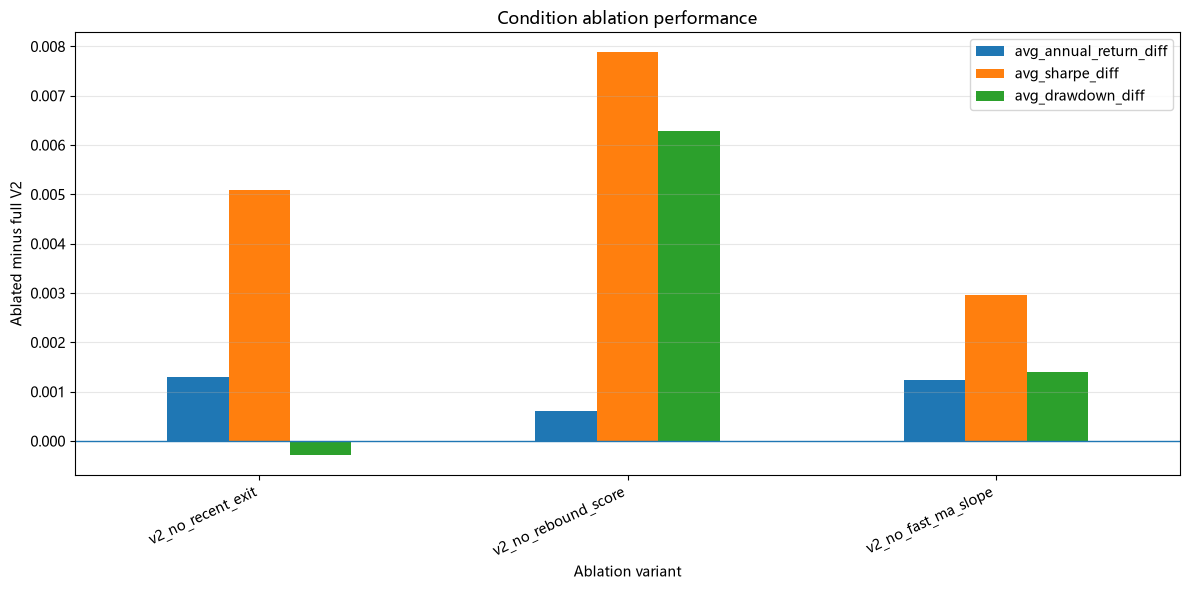

In [13]:
plot_data = (
    ablation_final_summary
    .set_index("candidate_name")
    [
        [
            "avg_annual_return_diff",
            "avg_sharpe_diff",
            "avg_drawdown_diff",
        ]
    ]
)

ax = plot_data.plot(
    kind="bar",
    figsize=(12, 6),
)

ax.axhline(
    0.0,
    linewidth=1.0,
)

ax.set_xlabel(
    "Ablation variant"
)

ax.set_ylabel(
    "Ablated minus full V2"
)

ax.set_title(
    "Condition ablation performance"
)

ax.grid(
    True,
    axis="y",
    alpha=0.3,
)

plt.xticks(
    rotation=25,
    ha="right",
)

plt.tight_layout()
plt.show()

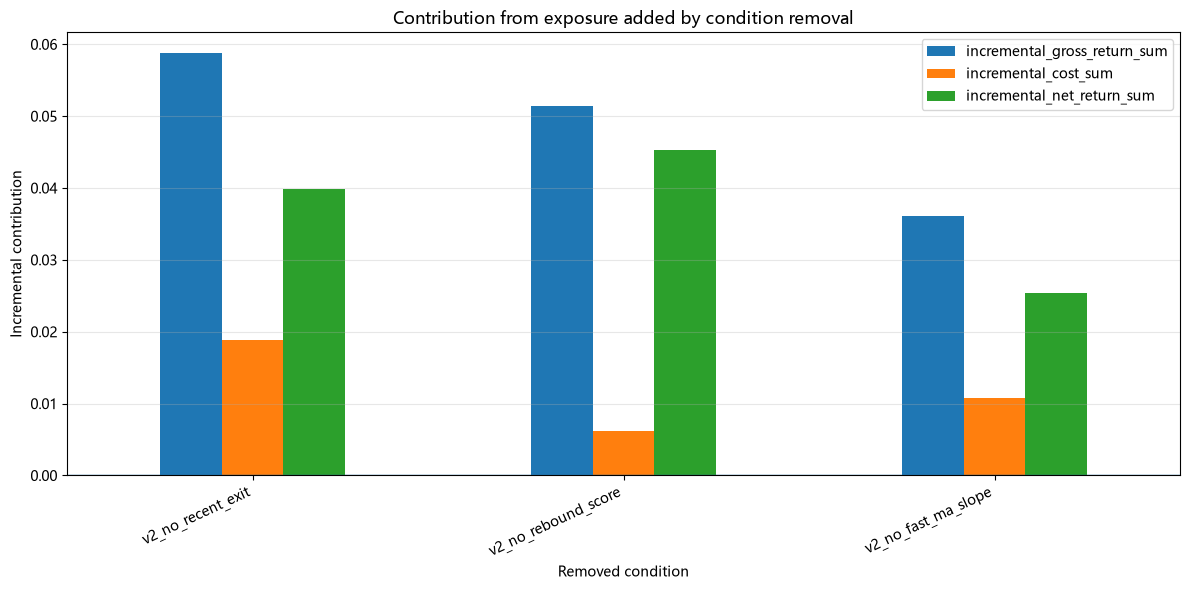

In [14]:
extra_exposure_plot = (
    removed_condition_effect
    .set_index("candidate_name")
    [
        [
            "incremental_gross_return_sum",
            "incremental_cost_sum",
            "incremental_net_return_sum",
        ]
    ]
)

ax = extra_exposure_plot.plot(
    kind="bar",
    figsize=(12, 6),
)

ax.axhline(
    0.0,
    linewidth=1.0,
)

ax.set_xlabel(
    "Removed condition"
)

ax.set_ylabel(
    "Incremental contribution"
)

ax.set_title(
    "Contribution from exposure added by condition removal"
)

ax.grid(
    True,
    axis="y",
    alpha=0.3,
)

plt.xticks(
    rotation=25,
    ha="right",
)

plt.tight_layout()
plt.show()

In [15]:
def classify_ablation_result(
    row: pd.Series,
) -> str:
    return_worse = (
        row[
            "avg_annual_return_diff"
        ] < 0
    )

    sharpe_worse = (
        row[
            "avg_sharpe_diff"
        ] < 0
    )

    drawdown_worse = (
        row[
            "avg_drawdown_diff"
        ] < 0
    )

    extra_exposure_loses = (
        row[
            "incremental_log_return_sum"
        ] < 0
    )

    return_better = (
        row[
            "avg_annual_return_diff"
        ] > 0
    )

    sharpe_better = (
        row[
            "avg_sharpe_diff"
        ] > 0
    )

    drawdown_not_materially_worse = (
        row[
            "avg_drawdown_diff"
        ] >= -0.003
    )

    if (
        extra_exposure_loses
        and sharpe_worse
        and drawdown_worse
    ):
        return "条件有明显价值，建议保留"

    if (
        return_better
        and sharpe_better
        and drawdown_not_materially_worse
    ):
        return "条件可能过严，考虑删除"

    if (
        np.isclose(
            row[
                "avg_annual_return_diff"
            ],
            0.0,
            atol=0.0005,
        )
        and np.isclose(
            row[
                "avg_sharpe_diff"
            ],
            0.0,
            atol=0.01,
        )
    ):
        return "边际影响较小，可能冗余"

    if return_worse or sharpe_worse:
        return "证据偏向保留，但不完全一致"

    return "证据混合，需要结合逐股票结果"

ablation_final_summary[
    "preliminary_decision"
] = (
    ablation_final_summary.apply(
        classify_ablation_result,
        axis=1,
    )
)

display(
    ablation_final_summary[
        [
            "candidate_name",
            "avg_annual_return_diff",
            "avg_sharpe_diff",
            "avg_drawdown_diff",
            "incremental_log_return_sum",
            "incremental_stock_win_rate",
            "preliminary_decision",
        ]
    ]
)

,candidate_name,avg_annual_return_diff,avg_sharpe_diff,avg_drawdown_diff,incremental_log_return_sum,incremental_stock_win_rate,preliminary_decision
0,v2_no_recent_exit,0.0013,0.0051,-0.0003,0.0351,0.8000,条件可能过严，考虑删除
1,v2_no_rebound_score,0.0006,0.0079,0.0063,0.0416,0.8000,条件可能过严，考虑删除
2,v2_no_fast_ma_slope,0.0012,0.0030,0.0014,0.0239,0.6000,条件可能过严，考虑删除


## 精细对比

In [16]:
stock_ablation_frames = []

for variant, comparison in (
    ablation_comparisons.items()
):
    stock_result = comparison[
        [
            "symbol",
            "strategy_annual_return_diff",
            "strategy_sharpe_diff",
            "strategy_max_drawdown_diff",
            "excess_annual_return_diff",
            "total_turnover_diff",
            "total_transaction_cost_diff",
        ]
    ].copy()

    stock_result[
        "candidate_name"
    ] = variant

    stock_ablation_frames.append(
        stock_result
    )

stock_ablation_detail = pd.concat(
    stock_ablation_frames,
    ignore_index=True,
)

display(
    stock_ablation_detail.sort_values(
        [
            "candidate_name",
            "strategy_sharpe_diff",
        ],
        ascending=[
            True,
            False,
        ],
    )
)


,symbol,strategy_annual_return_diff,strategy_sharpe_diff,strategy_max_drawdown_diff,excess_annual_return_diff,total_turnover_diff,total_transaction_cost_diff,candidate_name
12,600036,0.0046,0.0228,0.0100,0.0046,3.0000,0.0015,v2_no_fast_ma_slope
10,300750,0.0052,0.0099,0.0015,0.0052,4.2000,0.0021,v2_no_fast_ma_slope
13,000001,0.0015,0.0066,0.0047,0.0015,3.6000,0.0018,v2_no_fast_ma_slope
11,600519,-0.0010,-0.0046,-0.0047,-0.0010,6.0000,0.0030,v2_no_fast_ma_slope
14,000002,-0.0042,-0.0198,-0.0044,-0.0042,4.8000,0.0024,v2_no_fast_ma_slope
6,600519,0.0083,0.0376,0.0235,0.0083,2.4000,0.0012,v2_no_rebound_score
9,000002,0.0023,0.0135,0.0040,0.0023,2.1000,0.0010,v2_no_rebound_score
7,600036,0.0008,0.0044,0.0026,0.0008,3.0000,0.0015,v2_no_rebound_score
8,000001,0.0002,0.0011,0.0035,0.0002,3.0000,0.0015,v2_no_rebound_score
5,300750,-0.0086,-0.0172,-0.0021,-0.0086,1.8000,0.0009,v2_no_rebound_score


In [17]:
stock_stability_summary = (
    stock_ablation_detail.groupby(
        "candidate_name",
        as_index=False,
    )
    .agg(
        return_win_rate=(
            "strategy_annual_return_diff",
            lambda values: float(
                (values > 0).mean()
            ),
        ),
        sharpe_win_rate=(
            "strategy_sharpe_diff",
            lambda values: float(
                (values > 0).mean()
            ),
        ),
        drawdown_win_rate=(
            "strategy_max_drawdown_diff",
            lambda values: float(
                (values > 0).mean()
            ),
        ),
        worst_return_diff=(
            "strategy_annual_return_diff",
            "min",
        ),
        worst_sharpe_diff=(
            "strategy_sharpe_diff",
            "min",
        ),
    )
)

display(stock_stability_summary)

,candidate_name,return_win_rate,sharpe_win_rate,drawdown_win_rate,worst_return_diff,worst_sharpe_diff
0,v2_no_fast_ma_slope,0.6000,0.6000,0.6000,-0.0042,-0.0198
1,v2_no_rebound_score,0.8000,0.8000,0.8000,-0.0086,-0.0172
2,v2_no_recent_exit,0.8000,0.8000,0.6000,-0.0075,-0.0325


In [19]:
REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

ablation_summary_all.to_csv(
    REPORT_DIR
    / "ablation_summary_all.csv",
    index=False,
    encoding="utf-8-sig",
)

ablation_period_detail.to_csv(
    REPORT_DIR
    / "ablation_period_detail.csv",
    index=False,
    encoding="utf-8-sig",
)

ablation_performance_summary.to_csv(
    REPORT_DIR
    / "ablation_performance_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

signal_quality_summary.to_csv(
    REPORT_DIR
    / "signal_quality_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

removed_condition_effect.to_csv(
    REPORT_DIR
    / "removed_condition_effect.csv",
    index=False,
    encoding="utf-8-sig",
)

attribution_summary.to_csv(
    REPORT_DIR
    / "ablation_attribution_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

ablation_final_summary.to_csv(
    REPORT_DIR
    / "ablation_final_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

stock_ablation_detail.to_csv(
    REPORT_DIR
    / "stock_ablation_detail.csv",
    index=False,
    encoding="utf-8-sig",
)

stock_stability_summary.to_csv(
    REPORT_DIR
    / "stock_stability_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

print(
    "消融实验结果已保存：",
    REPORT_DIR,
)

消融实验结果已保存： e:\quant-learning\reports\ma_graded_position_ablation


## 分级仓位 v2 条件消融实验结论

### 1. 近期离场条件

- 移除后部分仓位比例变化：0.0275
- 移除后年化收益变化：0.0013
- 移除后夏普变化：0.0051	
- 移除后最大回撤变化：-0.0003
- 移除后换手变化：7.5600	
- 新增仓位累计净贡献：0.0398
- 新增仓位股票胜率：0.8
- 当前判断：暂时保留

### 2. 反弹强度条件

- 移除后部分仓位比例变化：0.0276
- 移除后年化收益变化：0.0006
- 移除后夏普变化：0.0079
- 移除后最大回撤变化：0.0063
- 移除后换手变化：2.4600
- 新增仓位累计净贡献：0.0453
- 新增仓位股票胜率：0.8
- 当前判断：删除

### 3. 快均线斜率条件

- 移除后部分仓位比例变化：0.0094
- 移除后年化收益变化：0.0012
- 移除后夏普变化：0.0030
- 移除后最大回撤变化：0.0014	
- 移除后换手变化：4.3200
- 新增仓位累计净贡献：0.0253
- 新增仓位股票胜率：0.6
- 当前判断：暂时保留

### 4. 最终规则选择

- 当前3个条件消融后策略表现均变好，相比之下反弹强度条件删除后策略表现最好，因此本轮仅删除反弹强度条件，暂时保留剩下两个条件
- 可以删除的条件：反弹强度
- 简化后规则：近期离场+快均线斜率
- 是否需要再次运行组合消融：需要
- 是否可以冻结规则：否
- 是否可以进入新样本验证：否

明确删除：
反弹强度条件

尚未确定：
近期离场条件
快均线斜率条件

下一候选基准：
近期离场 + 快均线斜率

下一轮实验：
近期离场单独
快均线斜率单独
两个条件全部删除